# CLASS-OneLoop Tutorial
### (18.07.2024 Split)

In [1]:
# Import classy and other modules
from classy import Class
import numpy as np
import matplotlib.pyplot as plt
import time

In [2]:
# To start the demo in clean conditions, erase any previous folder 'loop_matrices' and create a clean one
from shutil import rmtree
rmtree('loop_matrices/')
from os import mkdir
mkdir('loop_matrices/')  

## Initializing CLASS

In [3]:
# Create an instance of class, "model", and set cosmological parameters 
model=Class()
model.set({
    'omega_b':'0.022445',
    'omega_cdm':'0.1200',
    'h':'0.6736',
    'n_s':'0.9649',
    'A_s':'2.100549e-09'
})

True

In [4]:
# Set parameters specific to OneLoop module
# We require a full calculation of spectrum in redhsift space,
# including the initial calculation of the loop kernels, which is slow 
model.set({
    ######################################################################################
    # General settings: compute power spectrum with OneLoop module including RSD
    'output':'mPk',                         # [default: nothing, only background]
    'non_linear':'oneloopPT',               # [default: 'none']
    'has_rsd':'yes',                        # [default: 'no']
    #######################################################################################
    # Parameters related to loop kernel calculation:
    'eft_compute_loop_matrices':'yes',      # full calculation of the loop kernels (bottleneck) [default: 'yes']
    # After the first run, **the loop kernels will be cached in memory** as long as the notebook is alive
    # They could also be written in files for future runs if we would set the following flag to 'yes':
    'eft_write_loop_matrices':'no',         # [default: 'no']
    'eft_loop_matrix_dir':'loop_matrices/', # [default: 'loop_matrices/']
    ########################################################################################
    # Parameters related to logarithmic Fourier Transform (logFT)
    'eft_direct_integration':'no',          # switches off full integration, in favour of logFT approach [default: 'no']
    'eft_fourier_mode':1,                   # either Fast Fourier Transform (FFTlog, =0) 
                                            # or Spline Fourier Transform (SFTlog, =1) [default: 1]
    'eft_num_positive_frequencies':96,      # number of logFT coefficients 
                                            # (with SFTlog, 96 accurate enough; with FFTlog, 256 is better) [default: 128]
    ######################################################################################### 
    # Parameter related to redshift
    # With following settings, loops computed at z=0, then P(k,z) can be rescaled up to z_max=2 using D(z) and f(z)
    'eft_use_eds_scaling':'yes',            # [default: 'yes']
    'z_max_pk':2.,                          # [default: 0]
    'z_pk_eft':0.                           # [default: 0]
    # There exists other settings were loops are explicitely computed at several redshifts, e.g.:
    # 'z_pk_eft' : '0, 0.5, 1, 1.5'
    # This would lead to better accuracy in models with scale-dependent growth factor/rate, like with massive neutrinos
    ##########################################################################################
})

True

### Running CLASS for the 1-st time

In [5]:
# Run CLASS with a timer. If this is the first run, loop kernels are not cached, and the code is slow (~3 seconds?)
# The code will:
# - compute the linear power spectrum
# - compute the loop kernels
# However the SFT/FFTlog expansion of the linear spectrum and its contraction with the kernels will be done later,
# at the time when the output P(k,z) will be requested
start = time.time()
model.compute()
end = time.time()
print("Running CLASS including full loop kernel calculation (bottleneck) took %3.2g seconds"%(end-start))

Running CLASS including full loop kernel calculation (bottleneck) took 2.8 seconds


## Computing the Power Spectrum Wedges for Biased Tracers

In [6]:
# Set up the power spectrum output format: values of z, of mu, range of k....
z     = [0.5, 1.5]
mu    = [0, 0.5, 1]
k_min = 0.001
k_max = 0.25
knum  = 500

# Transform these arrays into the data type expected by classy functions
nbin  = len(z)
nmu   = len(mu)
z     = np.array(z, 'float64')                                                              #[index_z]
mu    = np.tile(np.array(mu, dtype='float64'), (nbin, 1))                                   #[index_z, index_mu]
k     = np.tile(np.logspace(np.log10(k_min), np.log10(k_max), num=knum), (nbin, nmu, 1))    #[index_z, index_mu, index_k]

In [7]:
# Set up nuisance parameters (biases and counter terms) 
# May enter a different set at each redshift
# In this demo we take the same values at each redhsift for simplicity
# inv_n = inverse of galaxy number density, in [Mpc/h]**3
b1, b2, bG2, btd   = 1., -0.7, -0.2 , 0.2
c00, c10, c22, c32 = -10., 20., 20., 20.
inv_n, s0, s1, s2, s3 = 1.e2, 0., 0., 0., 0.
biases = np.tile(np.array([b1, b2, bG2, btd], dtype='float64'), (nbin, 1))                  #[index_z, index_bias]
counters = np.tile(np.array([c00, c10, 0., c22, 0., c32, 0.], dtype='float64'), (nbin,1))   #[index_z, index_counter]
stochastics = np.tile(np.array([inv_n, s0, s1, s2, s3], dtype='float64'), (nbin,1))         #[index_z, index_stochastic]

### Computing the Power Spectrum for the 1-st time

In [8]:
# Compute the oneloop power spectrum wedges for biased tracers in redshift space
# The code will:
# - find logFT coefficients of the linear spectrum (result will remain cached as long as .compute not called again)
# - contract them with each loop kernels (result will remain cached as long as .compute not called again)
# - assemble loop contributions to form output spectrum
start = time.time()
P1 = model.eft_pkmu_rsd_stoch_grid(mu,k,z,
       biases,
       counters,
       stochastics,
       'Pdd_hh_rsd') # Get halo power spectrum with RSD
                     # Other options for matter power spectrum and/or real space: 'Pdd_mm_real', 'Pdd_mm_rsd', 'Pdd_hh_real'
end = time.time()
print("Without re-runing CLASS, extracting P_oneloop took %3.2g seconds"%(end-start))

Without re-runing CLASS, extracting P_oneloop took 0.054 seconds


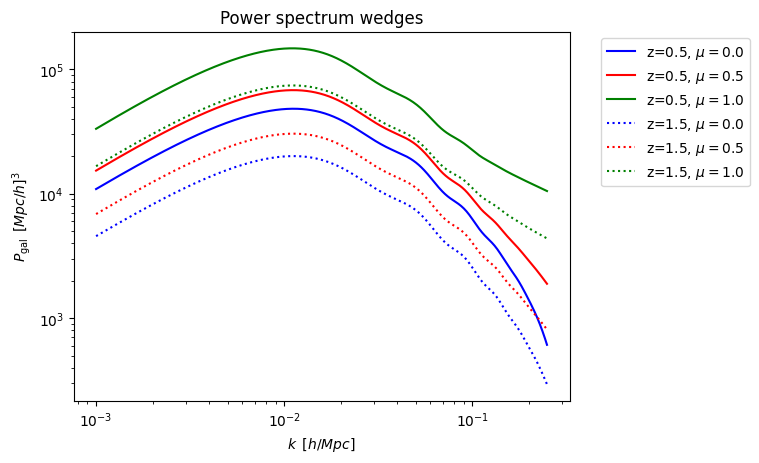

In [9]:
# Plot the oneloop power spectrum wedges for biased tracers in redshift space
plt.subplot(111)
plt.loglog()
plt.gca().set_prop_cycle(None)
ls = ['-',':']
col = ['b','r','g']
for z_ind in range(len(z)):
    for mu_ind in range(nmu):
        plt.plot(k[z_ind][mu_ind], P1[z_ind][mu_ind], label="z=%s, $\mu=%s$" % (z[z_ind],mu[z_ind][mu_ind]),linestyle=ls[z_ind],color=col[mu_ind])
plt.xlabel("$k \,\,\, [h/Mpc]$")
plt.ylabel(r"$P_{\rm gal} \,\,\, [Mpc/h]^3$")
plt.title("Power spectrum wedges")
plt.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')

### Computing the Power Spectrum for the 2-nd time

In [10]:
# Set up different nuisance parameters, no need to rerun CLASS
b1, b2, bG2, btd   = 1.1, -0.75, -0.22 , 0.18
c00, c10, c22, c32 = -0., 22., 19., 22.
inv_n, s0, s1, s2, s3 = 1.e2, 0., 0., 0., 0.
biases = np.tile(np.array([b1, b2, bG2, btd], dtype='float64'), (nbin, 1))                  #[index_z, index_bias]
counters = np.tile(np.array([c00, c10, 0., c22, 0., c32, 0.], dtype='float64'), (nbin,1))   #[index_z, index_counter]
stochastics = np.tile(np.array([inv_n, s0, s1, s2, s3], dtype='float64'), (nbin,1))         #[index_z, index_stochastic]

In [11]:
# Compute the oneloop power spectrum wedges for biased tracers in redshift space
# The code does not need to recompute each loop contributions,
# it only needs to take a different combination of them and assemble them to form the output spectrum
start = time.time()
P2 = model.eft_pkmu_rsd_stoch_grid(mu,k,z,
       biases,
       counters,
       stochastics,
       'Pdd_hh_rsd') # Other options for matter power spectrum and/or real space: 'Pdd_mm_real', 'Pdd_mm_rsd', 'Pdd_hh_real'
end = time.time()
print("Without re-runing CLASS, extracting another P_oneloop took %3.2g seconds"%(end-start))
print("This shows that nuisance parameters would play the role of fast parameters in an MCMC")

Without re-runing CLASS, extracting another P_oneloop took 0.007 seconds
This shows that nuisance parameters would play the role of fast parameters in an MCMC


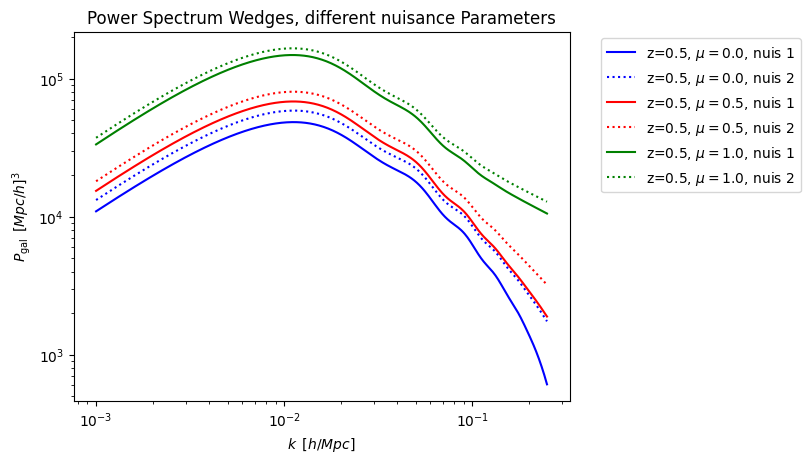

In [16]:
# Plot the oneloop power spectrum wedges for biased tracers in redshift space
plt.loglog()
z_ind=0
for mu_ind in range(nmu):
    plt.plot(k[z_ind][mu_ind], P1[z_ind][mu_ind], label="z=%s, $\mu=%s$, nuis 1" % (z[z_ind],mu[z_ind][mu_ind]),linestyle=ls[0],color=col[mu_ind])
    plt.plot(k[z_ind][mu_ind], P2[z_ind][mu_ind], label="z=%s, $\mu=%s$, nuis 2" % (z[z_ind],mu[z_ind][mu_ind]),linestyle=ls[1],color=col[mu_ind])
plt.xlabel("$k \,\,\, [h/Mpc]$")
plt.ylabel(r"$P_{\rm gal} \,\,\, [Mpc/h]^3$")
plt.title("Power Spectrum Wedges, different nuisance Parameters")
plt.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')

## Running CLASS a 2-nd time on a different Cosmology

In [13]:
# Define new set of cosmological parameters
model.set({
    'omega_b':'0.023',
    'omega_cdm':'0.1200',
    'h':'0.68',
    'n_s':'0.997',
    'A_s':'2.1e-09'
})

True

In [14]:
# Run CLASS with a timer. If this is the second run, loop kernels taken from cache and code is fast (10^-4 seconds?)
# The code will:
# - compute the linear power spectrum
# That's all. The loop kernels are already cached.
# The logFT expansion of the linear spectrum and its contraction with the kernels will be done later,
# at the time when the output P(k,z) will be requested
start = time.time()
model.compute()
end = time.time()
print("Running CLASS without the full loop kernel calculation took %3.2g seconds (total for all modules + OneLoop)"%(end-start))
print("This would be the time taken by CLASS when changing slow parameters in an MCMC")

Running CLASS without the full loop kernel calculation took 0.1 seconds (total for all modules + OneLoop)
This would be the time taken by CLASS when changing slow parameters in an MCMC


### Compute the corresponding Power Spectrum

In [15]:
# Use the same set of nuisance parameters as in first example
b1, b2, bG2, btd   = 1., -0.7, -0.2 , 0.2
c00, c10, c22, c32 = -10., 20., 20., 20.
inv_n, s0, s1, s2, s3 = 1.e2, 0., 0., 0., 0.
biases = np.tile(np.array([b1, b2, bG2, btd], dtype='float64'), (nbin, 1))                  #[index_z, index_bias]
counters = np.tile(np.array([c00, c10, 0., c22, 0., c32, 0.], dtype='float64'), (nbin,1))   #[index_z, index_counter]
stochastics = np.tile(np.array([inv_n, s0, s1, s2, s3], dtype='float64'), (nbin,1))         #[index_z, index_stochastic]

In [16]:
# Compute the oneloop power spectrum wedges for biased tracers in redshift space
# The code will:
# - find logFT coefficients of the linear spectrum (result will remain cached as long as .compute() not called again)
# - contract them with each loop kernels (result will remain cached as long as .compute() not called again)
# - assemble loop contributions into single output spectrum
start = time.time()
P3 = model.eft_pkmu_rsd_stoch_grid(mu,k,z,
       biases,
       counters,
       stochastics,
       'Pdd_hh_rsd') # Other options for matter power spectrum and/or real space: 'Pdd_mm_real', 'Pdd_mm_rsd', 'Pdd_hh_real'
end = time.time()
print("Extracting P_oneloop took %3.2g seconds"%(end-start))

Extracting P_oneloop took 0.05 seconds


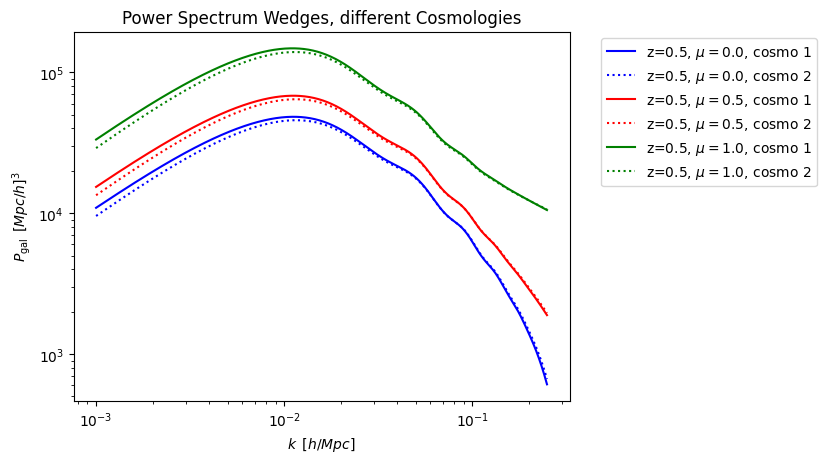

In [24]:
# Plot the oneloop power spectrum wedges for biased tracers in redshift space
plt.subplot(111)
plt.loglog()
z_ind = 0
for mu_ind in range(nmu):
    plt.plot(k[z_ind][mu_ind], P1[z_ind][mu_ind], label="z=%s, $\mu=%s$, cosmo 1" % (z[z_ind],mu[z_ind][mu_ind]),linestyle=ls[0],color=col[mu_ind])
    plt.plot(k[z_ind][mu_ind], P3[z_ind][mu_ind], label="z=%s, $\mu=%s$, cosmo 2" % (z[z_ind],mu[z_ind][mu_ind]),linestyle=ls[1],color=col[mu_ind])
plt.xlabel("$k \,\,\, [h/Mpc]$")
plt.ylabel(r"$P_{\rm gal} \,\,\, [Mpc/h]^3$")
plt.title("Power Spectrum Wedges, different Cosmologies")
plt.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')

## Compute the Power Spectrum Multipoles

In [18]:
# To get the power spectrum mutipoles: 
# - define an array of k(z) values (without mu as extra argument)
# - define the Alcock-Paczynski ratios H^fid(z)/H^true(z) (here we take fid=true and fill this array with ones)
# - define the Alcock-Paczynski ratios D_A^true(z)/D_A^fid(z) (here we take fid=true and fill this array with ones)
kk = np.tile(np.logspace(np.log10(k_min), np.log10(k_max), num=knum), (nbin, 1))    #[index_z, index_k]
ap_parallel = np.ones_like(z)
ap_perpendicular = np.ones_like(z)

In [19]:
# Compute the oneloop power spectrum **multipoles** for biased tracers in redshift space
# The code does not need to recompute each loop contributions,
# it only needs to take a different combination of them
# and perform the Legendre expansion
start = time.time()
P4 = model.eft_pkl_rsd_grid(kk,z,
       ap_parallel,
       ap_perpendicular,
       biases,
       counters,
       'Pdd_hh_rsd') # Other option for matter power spectrum: Pdd_mm_rsd'
end = time.time()
print("Extracting P_oneloop took %3.2g seconds"%(end-start))

Extracting P_oneloop took 0.0054 seconds


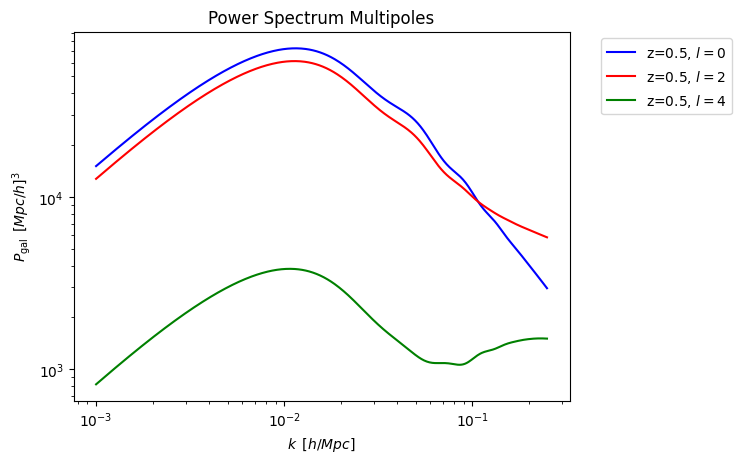

In [23]:
# Plot the oneloop power spectrum multipoles for biased tracers in redshift space
plt.subplot(111)
plt.loglog()
z_ind = 0
for ll in range(3):
    plt.plot(kk[z_ind], P4[z_ind][ll], label="z=%s, $l=%s$" % (z[z_ind],ll*2),linestyle=ls[0],color=col[ll])
plt.xlabel("$k \,\,\, [h/Mpc]$")
plt.ylabel(r"$P_{\rm gal} \,\,\, [Mpc/h]^3$")
plt.title("Power Spectrum Multipoles")
plt.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')